

## The Data


Source: https://archive.ics.uci.edu/ml/datasets/Wholesale+customers



Attribute Information:

    1) FRESH: annual spending (m.u.) on fresh products (Continuous);
    2) MILK: annual spending (m.u.) on milk products (Continuous);
    3) GROCERY: annual spending (m.u.)on grocery products (Continuous);
    4) FROZEN: annual spending (m.u.)on frozen products (Continuous)
    5) DETERGENTS_PAPER: annual spending (m.u.) on detergents and paper products (Continuous)
    6) DELICATESSEN: annual spending (m.u.)on and delicatessen products (Continuous);
    7) CHANNEL: customers  Channel - Horeca (Hotel/Restaurant/CafÃ©) or Retail channel (Nominal)
    8) REGION: customers  Region Lisnon, Oporto or Other (Nominal)

-----

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from charset_normalizer.md import annotations

In [72]:
df = pd.read_csv('wholesome_customers_data.csv')

In [73]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


<Axes: xlabel='Milk', ylabel='Grocery'>

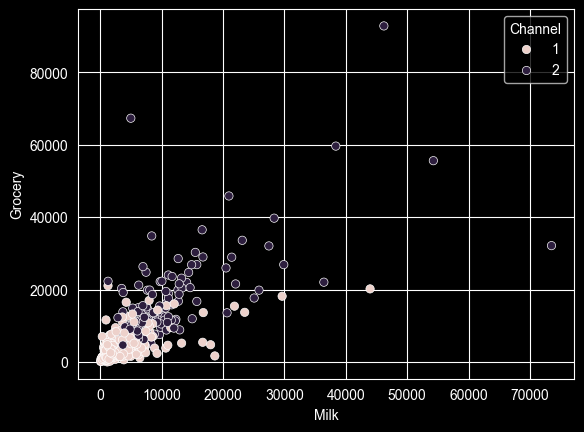

In [75]:
sns.scatterplot(data = df ,x = df['Milk'],y = df['Grocery'],hue=df['Channel'])

<Axes: xlabel='Milk', ylabel='Count'>

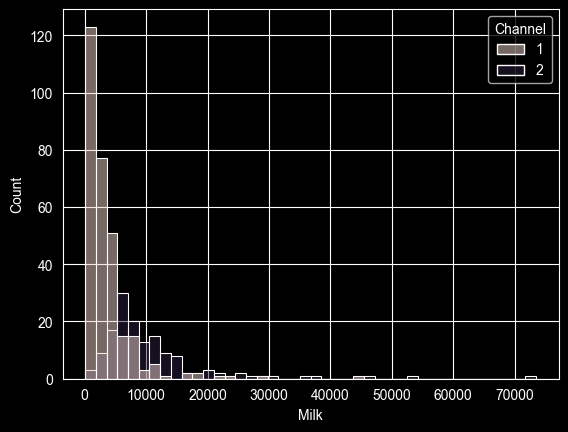

In [76]:
sns.histplot(data = df , x = df['Milk'],hue=df['Channel'])

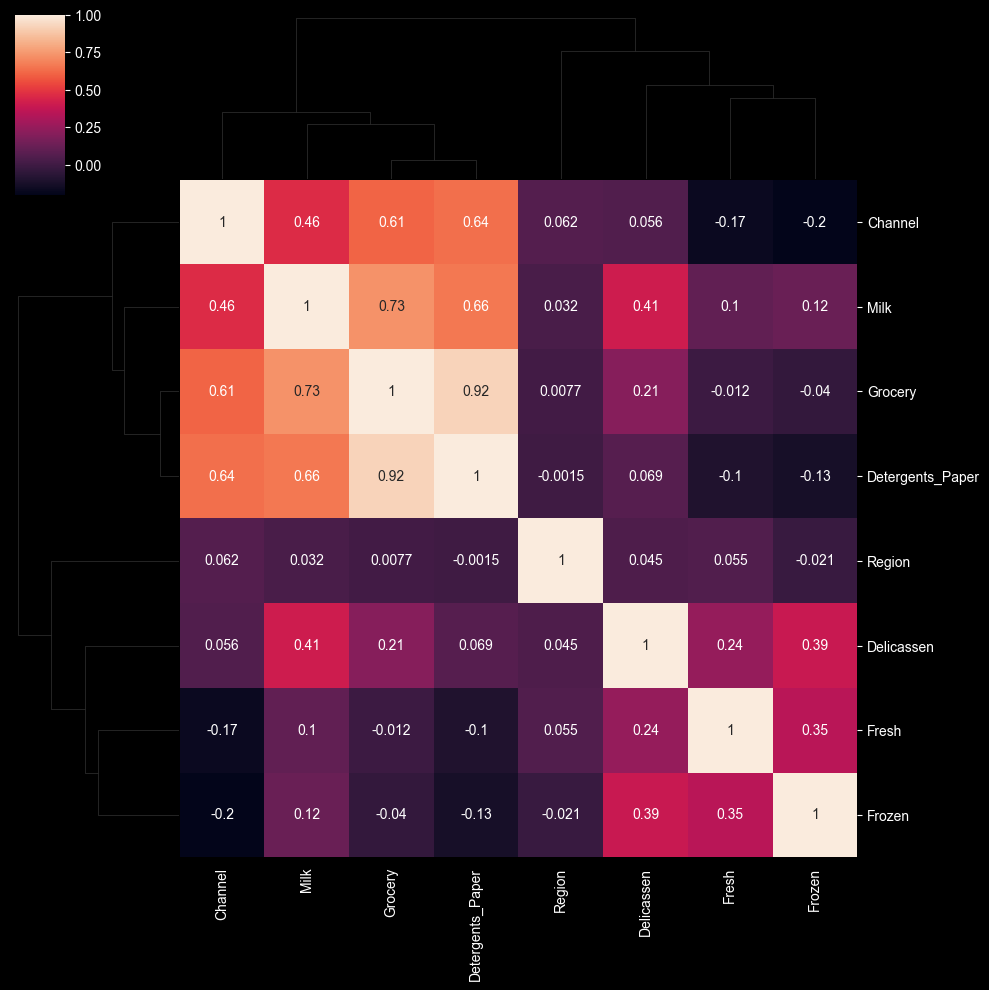

In [77]:
sns.clustermap(data  = df.corr(numeric_only=True),annot = True)

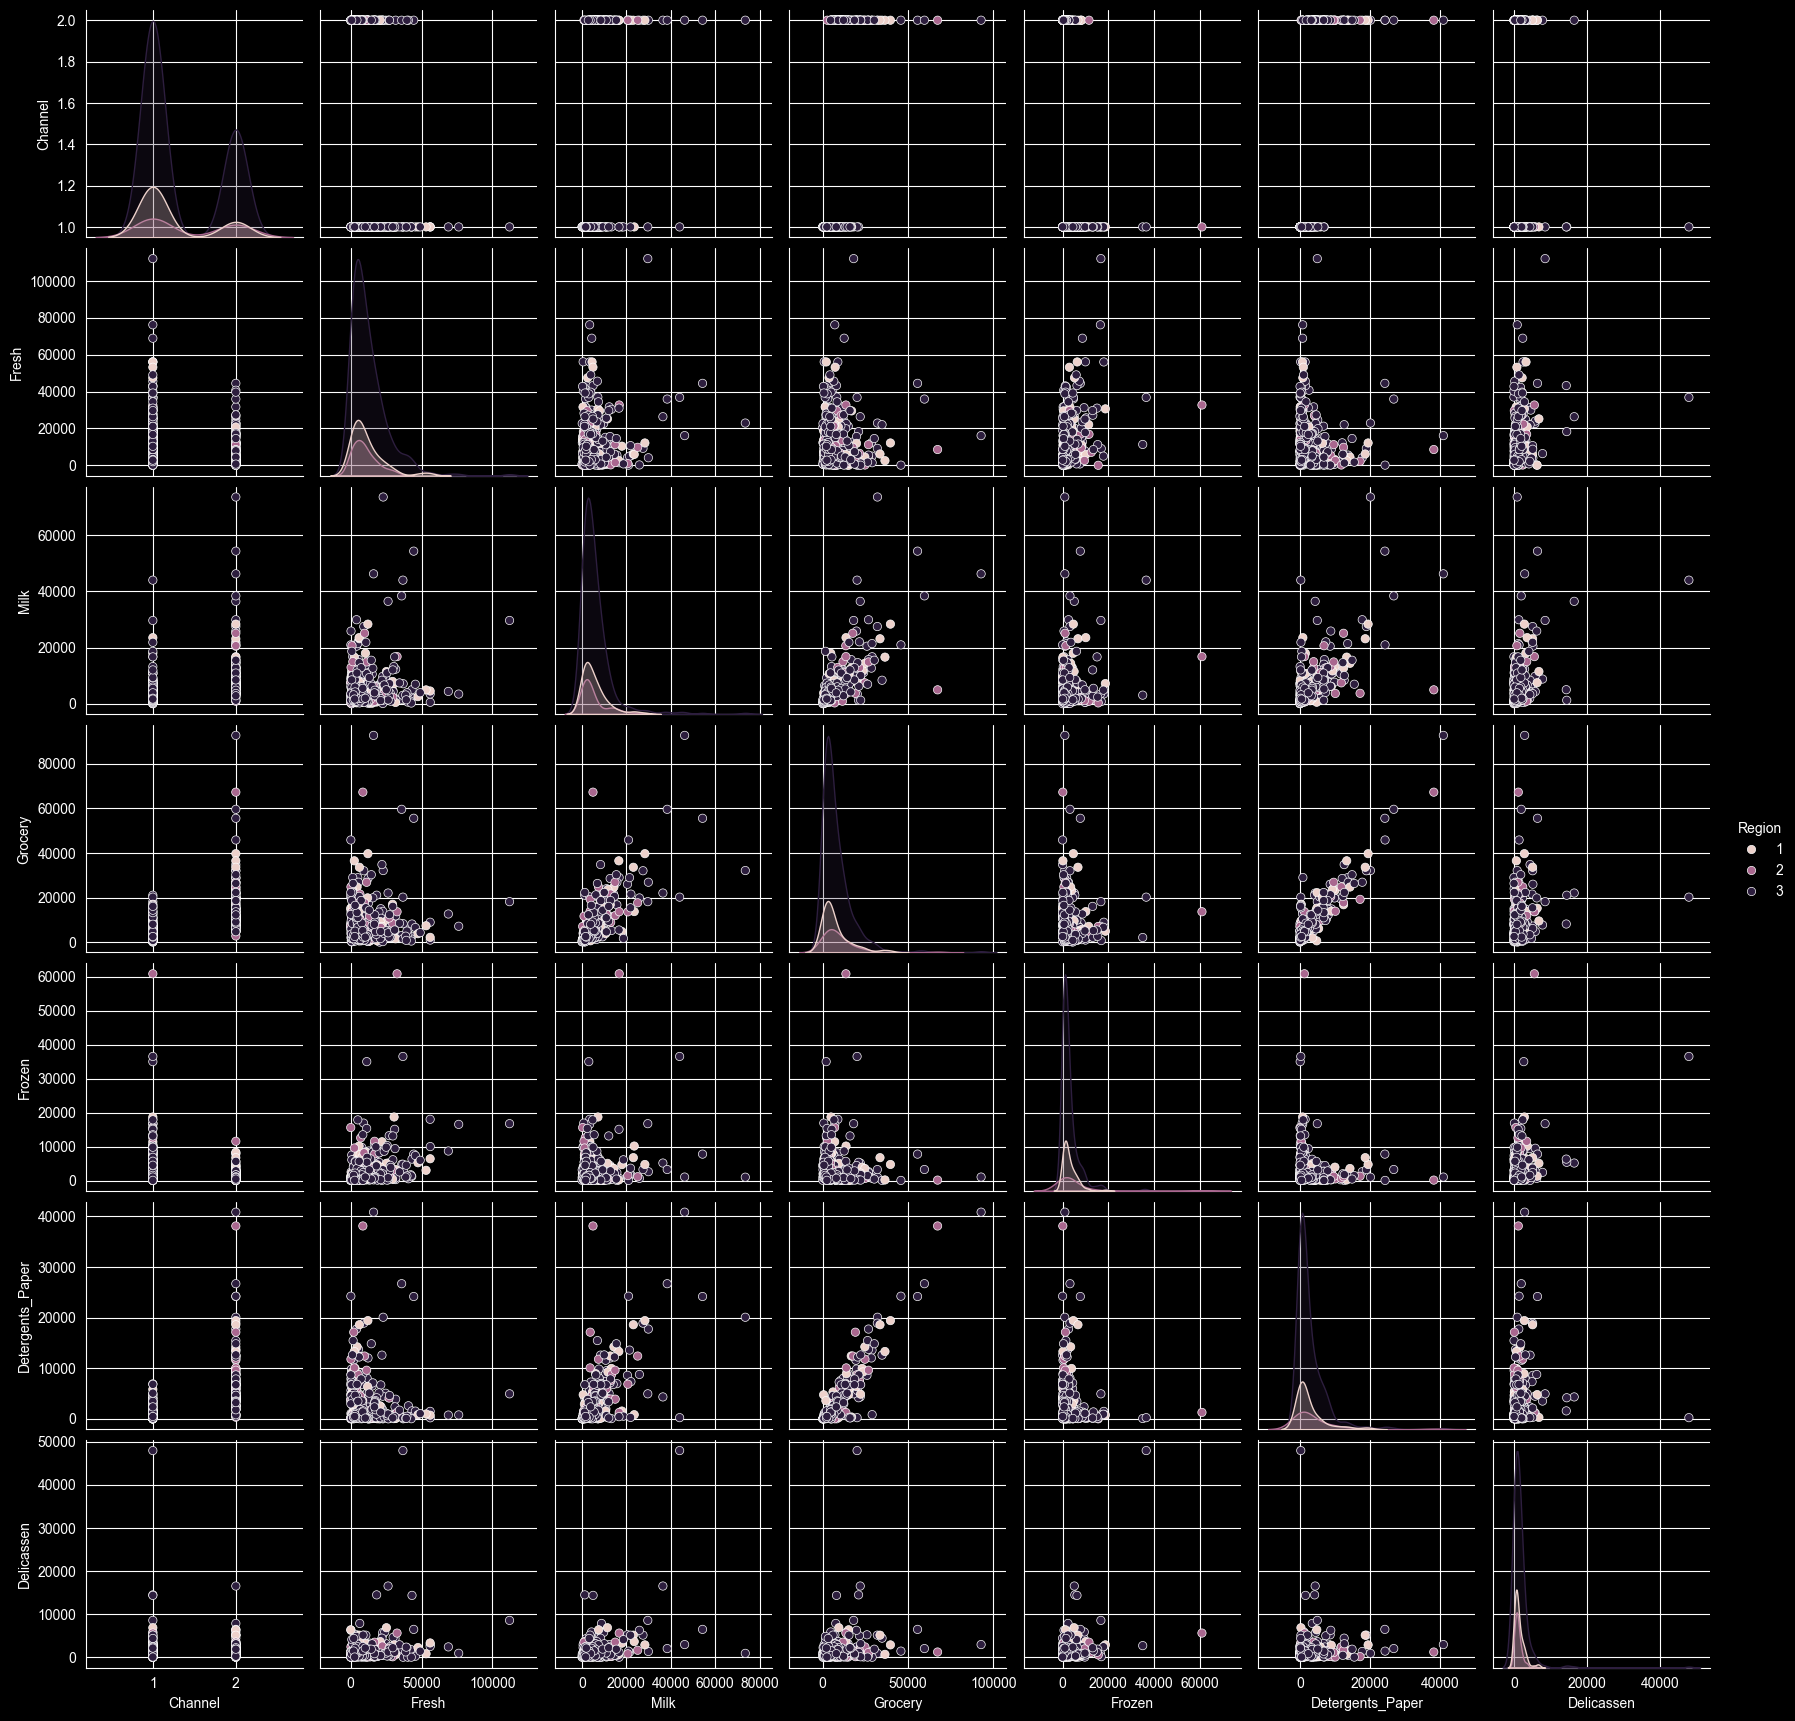

In [78]:
sns.pairplot(df,hue='Region')

In [79]:
from sklearn.preprocessing import  StandardScaler

In [80]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [81]:
scaled_data

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]], shape=(440, 8))

In [82]:
from sklearn.cluster import DBSCAN

In [83]:
outlier_percent = []
num_of_outlier = []
for eps in np.linspace(0.001,3,50):
    dbscan = DBSCAN(eps = eps,min_samples=2*scaled_data.shape[1])
    dbscan.fit(scaled_data)
    total_outLiars = np.sum(dbscan.labels_==-1)
    num_of_outlier.append(total_outLiars)
    percentage_of_outLiers = 100 * np.sum(total_outLiars) / len(dbscan.labels_)
    outlier_percent.append(percentage_of_outLiers)



<Axes: >

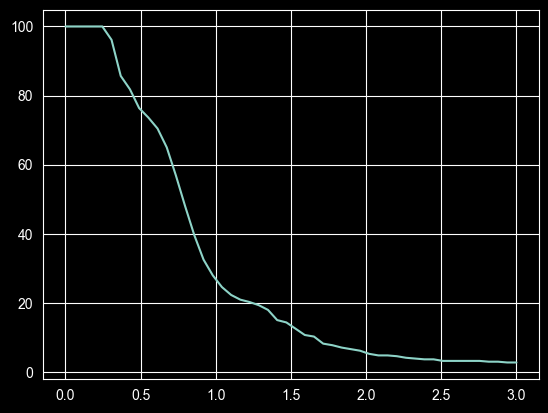

In [84]:
sns.lineplot(x = np.linspace(0.001,3,50) , y = outlier_percent)

In [85]:
model= DBSCAN(eps=2,min_samples=scaled_data.shape[1])

In [86]:
model.fit(scaled_data)

,eps,2
,min_samples,8
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


<Axes: xlabel='Milk', ylabel='Grocery'>

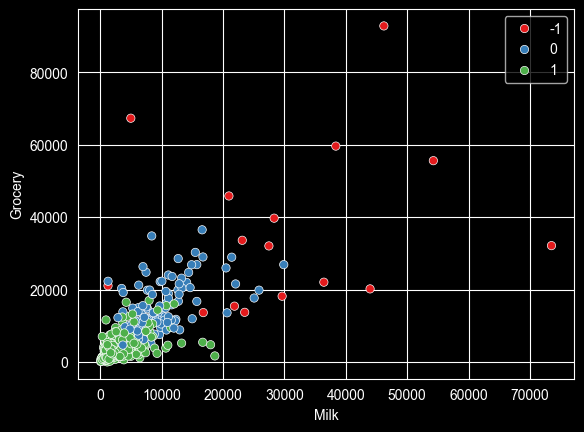

In [87]:
sns.scatterplot(data= df , x = df['Milk'],y=df['Grocery'],hue=model.labels_
                ,palette='Set1')

<Axes: xlabel='Milk', ylabel='Detergents_Paper'>

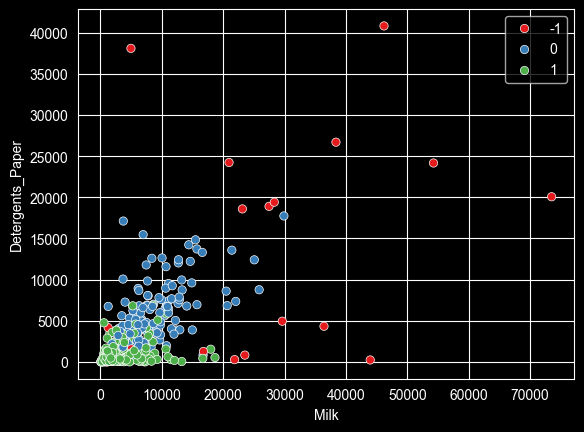

In [88]:
sns.scatterplot(data= df , x = df['Milk'],y=df['Detergents_Paper'],hue=model.labels_
                ,palette='Set1')

In [89]:
df['labels'] = pd.DataFrame(model.labels_)

In [90]:
cats = df.drop(['Channel','Region'],axis=1)
cat_means = cats.groupby('labels').mean()

In [91]:
cat_means

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels,,,,,,
-1,28678.285714,24176.523810,28797.857143,11535.000000,11932.523810,7367.380952
0,8134.862595,8909.916031,14004.427481,1450.595420,6080.832061,1533.519084
1,12542.430556,3039.760417,3677.871528,3192.315972,766.267361,1094.920139


In [96]:
from sklearn.preprocessing import MinMaxScaler
scaler  = MinMaxScaler()

In [97]:
cat_means_scaled = scaler.fit_transform(cat_means)

In [99]:
pd.DataFrame(cat_means_scaled,cat_means.index,cat_means.columns)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels,,,,,,
-1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
0,0.000000,0.277723,0.411089,0.000000,0.475949,0.069925
1,0.214549,0.000000,0.000000,0.172714,0.000000,0.000000


<Axes: ylabel='labels'>

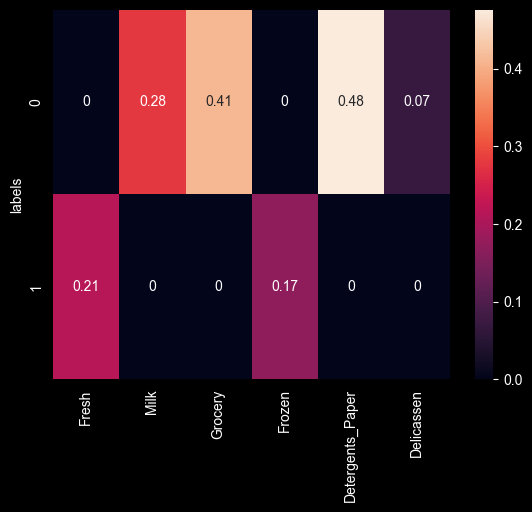

In [104]:
sns.heatmap(data = pd.DataFrame(cat_means_scaled,cat_means.index,cat_means.columns).loc[[0,1]],annot=True)

In [95]:
"Detergents_Pater And Milk Sepnding Categories were diff in Clusters !"